In [18]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [19]:
# 1. Lecture des données
df = pd.read_csv("PISA.csv")
print(df.head())
print("Dimensions :", df.shape)

   Score        GEP       PTR      UP   SC  SCR  TCH
0    510  18.846930  17.87578  85.701  211  177   81
1    495  23.188660  10.58415  57.715  292   13   60
2    401  20.201139  20.58529  85.770  171    3   37
3    446  22.360161  17.73363  73.990  258    7   50
4    528  17.615910  17.41596  81.259  291   74   59
Dimensions : (50, 7)


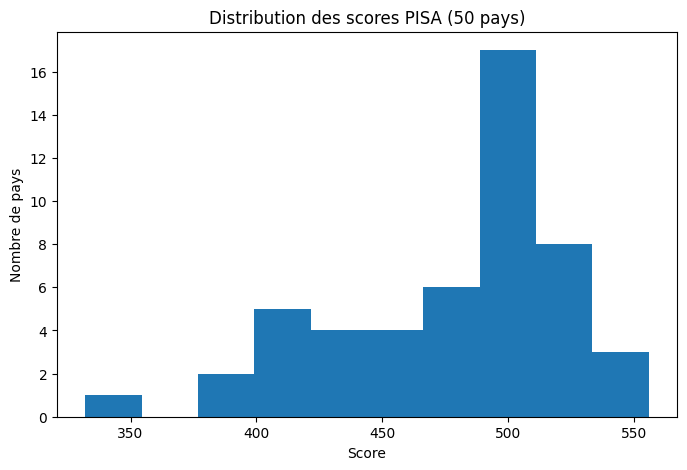

In [20]:
# 2. Histogramme de la colonne Score 
plt.figure(figsize=(8, 5))
plt.hist(df["Score"], bins=10)
plt.title("Distribution des scores PISA (50 pays)")
plt.xlabel("Score")
plt.ylabel("Nombre de pays")
plt.show()

In [21]:
# 3. Création de la colonne Score2 
# On choisit la médiane comme seuil m : 1 si le score est au-dessus, 0 sinon
m = df["Score"].median()
print("Seuil choisi (médiane) :", m)

df["Score2"] = (df["Score"] > m).astype(int)  # True → 1, False → 0
print(df[["Score", "Score2"]].head(10))

Seuil choisi (médiane) : 493.0
   Score  Score2
0    510       1
1    495       1
2    401       0
3    446       0
4    528       1
5    447       0
6    518       1
7    416       0
8    420       0
9    433       0


In [22]:
# 4. Création de l'arbre de décision
X = df.drop(columns=["Score", "Score2"])
y = df["Score2"]

# Séparation en train (70%) et test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

# On entraîne l'arbre uniquement sur les données d'entraînement
arbre = DecisionTreeClassifier(max_depth=3, random_state=100)
arbre.fit(X_train, y_train)
print("Arbre entraîné !")

Train : 35 lignes | Test : 15 lignes
Arbre entraîné !


In [23]:
# 5. Accuracy et matrice de confusion 
y_pred = arbre.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (test) : {acc:.2%}")

mc = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :")
print(pd.DataFrame(mc,
                   index=["Réel 0", "Réel 1"],
                   columns=["Prédit 0", "Prédit 1"]))

Accuracy (test) : 46.67%

Matrice de confusion :
        Prédit 0  Prédit 1
Réel 0         2         6
Réel 1         2         5


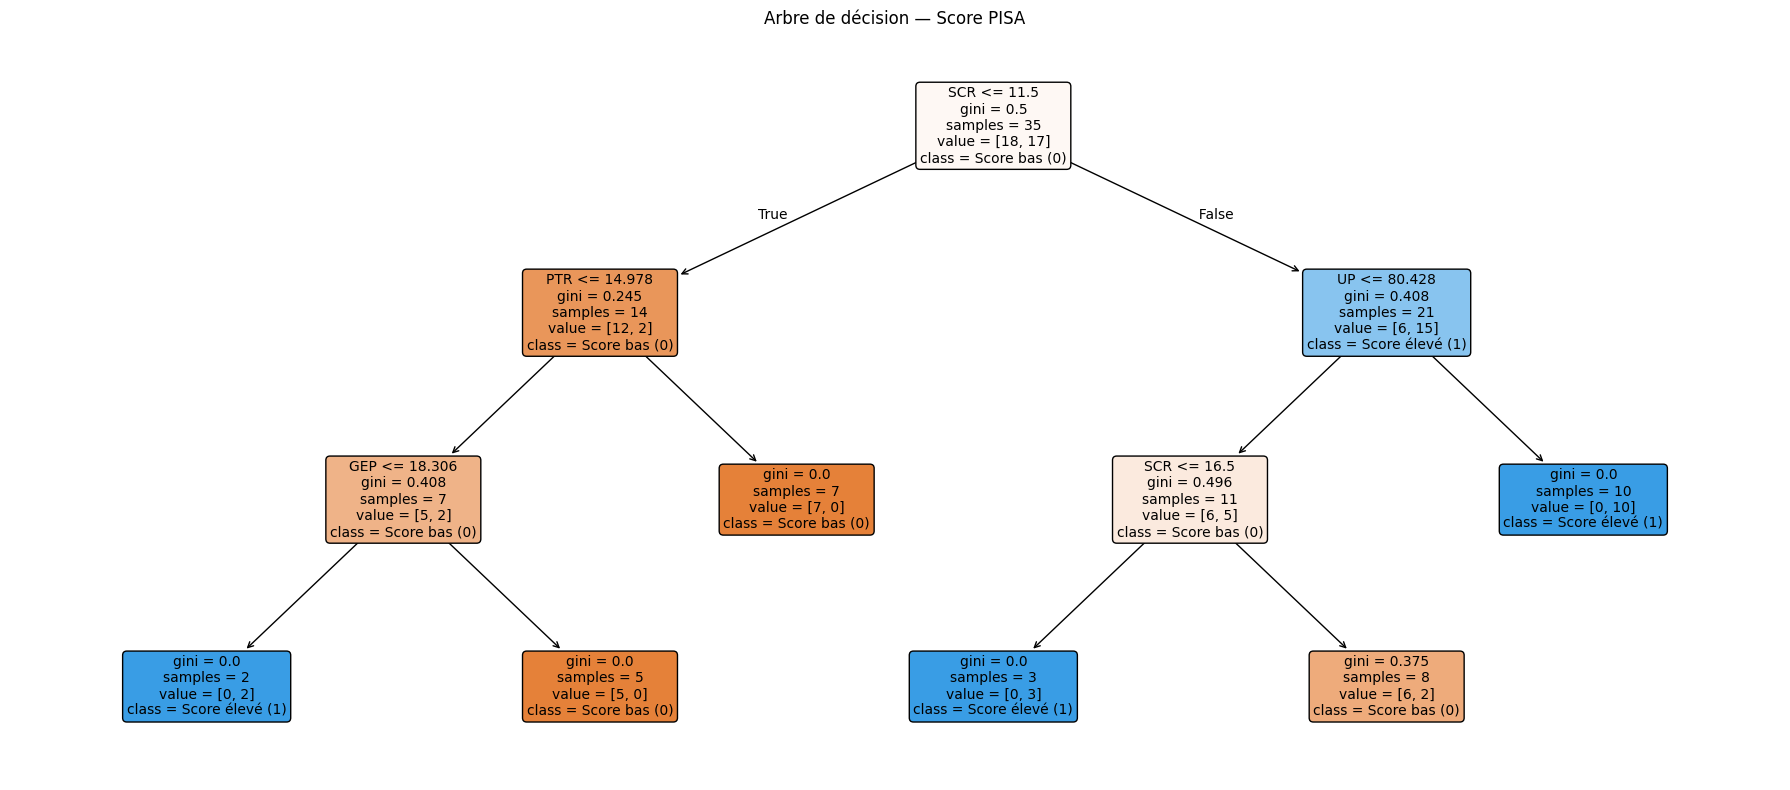

Règles de l'arbre :
|--- SCR <= 11.50
|   |--- PTR <= 14.98
|   |   |--- GEP <= 18.31
|   |   |   |--- class: 1
|   |   |--- GEP >  18.31
|   |   |   |--- class: 0
|   |--- PTR >  14.98
|   |   |--- class: 0
|--- SCR >  11.50
|   |--- UP <= 80.43
|   |   |--- SCR <= 16.50
|   |   |   |--- class: 1
|   |   |--- SCR >  16.50
|   |   |   |--- class: 0
|   |--- UP >  80.43
|   |   |--- class: 1



In [ ]:
# 6. Représentation graphique + règles de l'arbre
plt.figure(figsize=(18, 8))
plot_tree(arbre,
          feature_names=X.columns,
          class_names=["Score bas (0)", "Score élevé (1)"],
          filled=True,         # couleurs selon la classe majoritaire
          rounded=True,
          fontsize=10)
plt.title("Arbre de décision — Score PISA")
plt.tight_layout()
plt.show()

# Règles textuelles
print("Règles de l'arbre :")
print(export_text(arbre, feature_names=list(X.columns)))